In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Real-world Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset loaded: {data.target_names}")

Dataset loaded: ['malignant' 'benign']


In [5]:
# 3. Define Models and Hyperparameters
models_config = {
    'LogisticRegression (Baseline)': {
        'model': LogisticRegression(max_iter=10000),
        'params': {'C': [0.1, 1, 10]}
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [None, 10]}
    },
    'SVC': {
        'model': SVC(),
        'params': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
    }
}

# 4. Run GridSearch for each model
results = []

for name, config in models_config.items():
    print(f"Optimizing {name}...")
    clf = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy')
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': clf.best_params_,
        'Test Accuracy': acc
    })

# 5. Display Results
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
display(results_df)

Optimizing LogisticRegression (Baseline)...
Optimizing RandomForest...
Optimizing SVC...
Optimizing GradientBoosting...
Optimizing XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Model,Best Params,Test Accuracy
2,SVC,"{'C': 1, 'gamma': 'scale'}",0.982456
0,LogisticRegression (Baseline),{'C': 10},0.973684
1,RandomForest,"{'max_depth': None, 'n_estimators': 100}",0.964912
3,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 50}",0.956140
4,XGBoost,"{'learning_rate': 0.05, 'n_estimators': 50}",0.956140


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

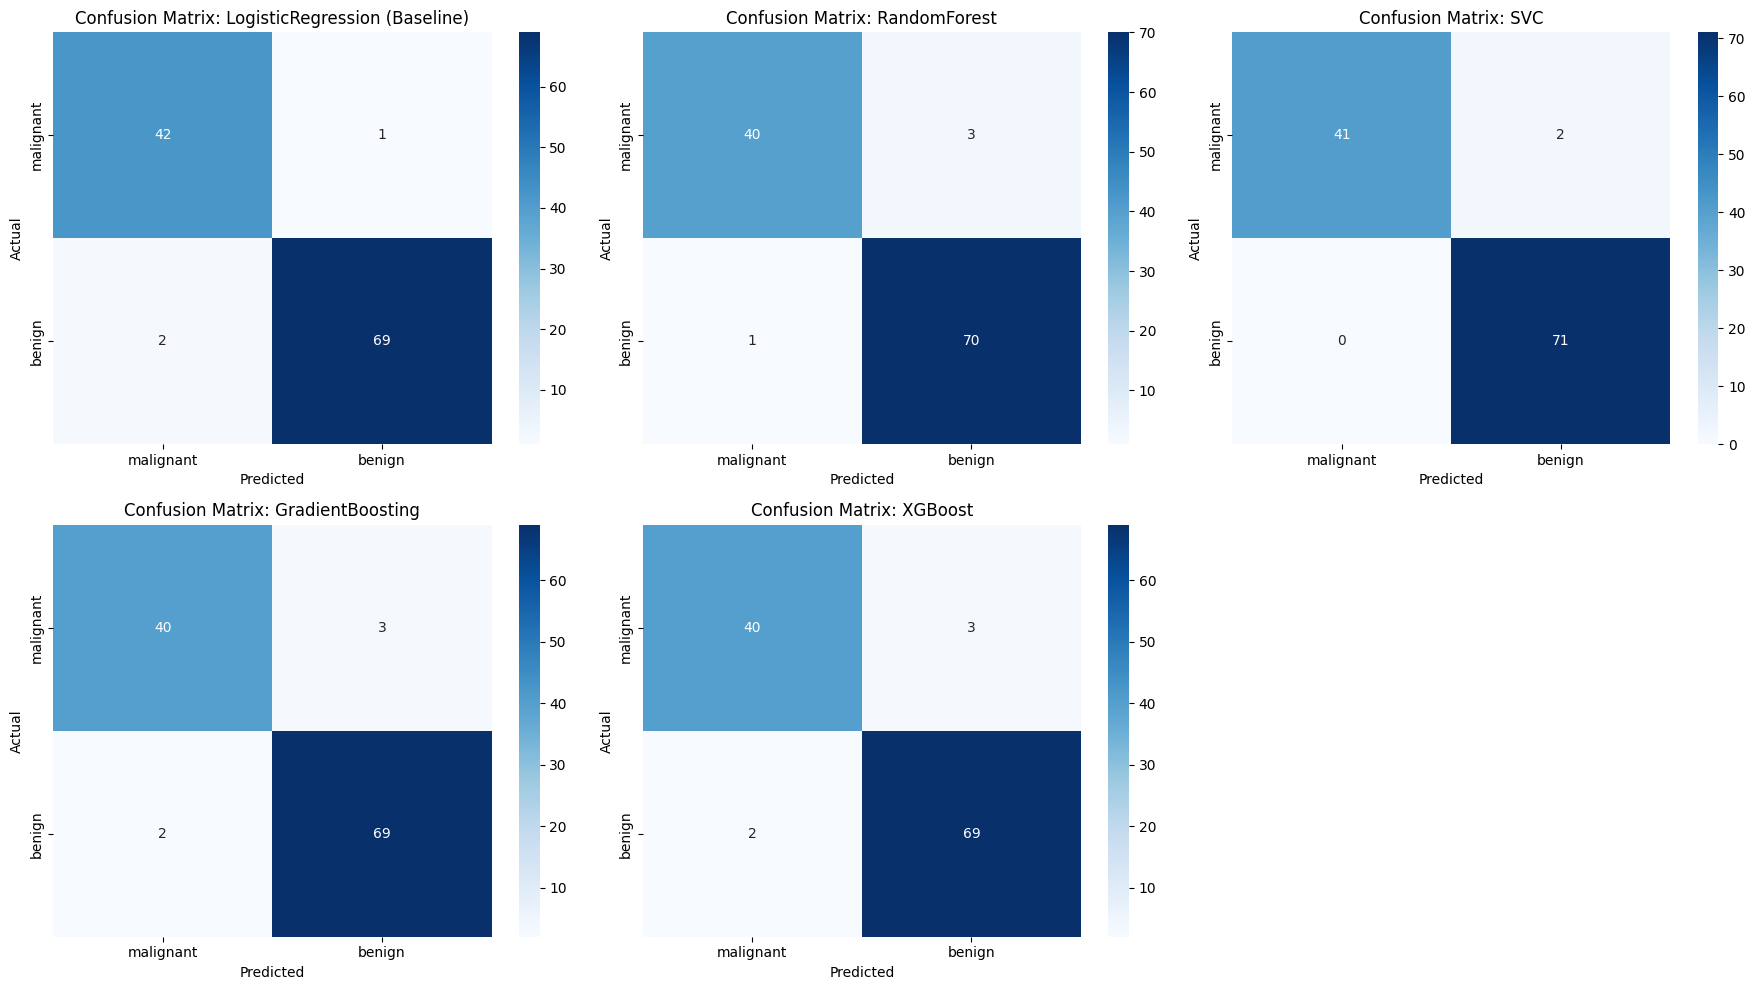

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set up the plotting area
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, config) in enumerate(models_config.items()):
    # Re-run the best estimator from our previous results
    # Note: Using GridSearchCV again briefly to fetch the best model based on previous results
    clf = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy')
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=data.target_names, yticklabels=data.target_names)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove the empty subplot if any
if len(models_config) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()